# ML Multi-Factor Strategy (LightGBM)

Machine learning approach to multi-factor stock selection:
- **Features**: ~60 engineered alpha factors from 350+ Qlib fields
- **Model**: LightGBM with walk-forward validation
- **Backtest**: TopkDropout(50) with CSI300 benchmark

This notebook replaces the linear ICIR-weighted composite with a non-linear model that captures factor interactions.

## 1. Setup & Data Loading

In [1]:
import os, sys, yaml, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

# ─── Project setup ───
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print(f'Project root: {PROJECT_ROOT}')

with open(os.path.join(PROJECT_ROOT, 'config.yaml'), 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)
QLIB_DIR = os.path.join(PROJECT_ROOT, config['storage']['qlib_data_dir'])
print(f'Qlib dir: {QLIB_DIR}')

Project root: e:\量化系统
Qlib dir: e:\量化系统\./data/qlib_data


In [2]:
import qlib
from qlib.data import D
from qlib.config import REG_CN

qlib.init(provider_uri=QLIB_DIR, region=REG_CN)
print('Qlib initialized')

# ─── Date ranges ───
FULL_START = '2012-01-01'
FULL_END   = '2025-12-31'
TRAIN_YEARS = 3   # rolling train window
VALID_YEARS = 1   # validation window
TEST_YEARS  = 1   # test / OOS window
FWD_DAYS    = 20   # forward return horizon (label)

print(f'Data range: {FULL_START} → {FULL_END}')
print(f'Walk-forward: {TRAIN_YEARS}yr train / {VALID_YEARS}yr valid / {TEST_YEARS}yr test')
print(f'Label: {FWD_DAYS}-day forward return')

[101048:MainThread](2026-03-06 14:40:12,751) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[101048:MainThread](2026-03-06 14:40:13,326) INFO - qlib.Initialization - [__init__.py:75] - qlib successfully initialized based on client settings.
[101048:MainThread](2026-03-06 14:40:13,327) INFO - qlib.Initialization - [__init__.py:77] - data_path={'__DEFAULT_FREQ': WindowsPath('E:/量化系统/data/qlib_data')}


Qlib initialized
Data range: 2012-01-01 → 2025-12-31
Walk-forward: 3yr train / 1yr valid / 1yr test
Label: 20-day forward return


## 2. Feature Engineering

We engineer ~60 features from Qlib's raw fields using Qlib expression operators.
Categories:
- **Price-Volume** (25): momentum, volatility, volume patterns, turnover
- **Fundamental** (20): valuation, profitability, leverage, growth
- **Technical** (10): mean-reversion signals, price position indicators
- **Cross-sectional** (5): rank-normalized features

In [3]:
%%time
# ─── Define feature expressions ───
# Qlib expression format: $field for raw, operators for derived

FEATURES = {}

# ── Price-Volume (25 features) ──────────────────────────
# Momentum at multiple horizons
for d in [5, 10, 20, 60, 120]:
    FEATURES[f'mom_{d}d'] = f'Ref($close,1)/$close - 1'  if d == 1 else f'Ref($close,1)/Ref($close,{d}) - 1'

# Volatility
for d in [5, 10, 20, 60]:
    FEATURES[f'vol_{d}d'] = f'Std($close/Ref($close,1)-1, {d})'

# Volume patterns
FEATURES['vol_ratio_5_20'] = 'Mean($vol, 5) / (Mean($vol, 20) + 1e-8)'
FEATURES['vol_ratio_5_60'] = 'Mean($vol, 5) / (Mean($vol, 60) + 1e-8)'
FEATURES['amt_ratio_5_20'] = 'Mean($amount, 5) / (Mean($amount, 20) + 1e-8)'

# Turnover
FEATURES['turnover_5d'] = 'Mean($turnover_rate, 5)'
FEATURES['turnover_20d'] = 'Mean($turnover_rate, 20)'
FEATURES['turnover_ratio'] = 'Mean($turnover_rate, 5) / (Mean($turnover_rate, 20) + 1e-8)'

# Price position
FEATURES['high_low_range_20'] = '($high - $low) / ($close + 1e-8)'
FEATURES['close_to_high_20'] = '$close / (Max($high, 20) + 1e-8)'
FEATURES['close_to_low_20'] = '$close / (Min($low, 20) + 1e-8)'

# Overnight return
FEATURES['overnight_ret_20'] = 'Mean($open/Ref($close,1)-1, 20)'

# VWAP deviation
FEATURES['vwap_dev_5'] = 'Mean($close - $amount/($vol+1e-8), 5)'

# ── Fundamental (20 features) ──────────────────────────
# Valuation
FEATURES['pe_ttm'] = '$pe_ttm'
FEATURES['pb'] = '$pb'
FEATURES['ps_ttm'] = '$ps_ttm'
FEATURES['dv_ttm'] = '$dv_ttm'  # dividend yield
FEATURES['ep_ttm'] = '1 / ($pe_ttm + 1e-8)'  # earnings yield

# Profitability
FEATURES['roe'] = '$roe'
FEATURES['roa'] = '$roa'
FEATURES['gross_margin'] = '$grossprofit_margin'
FEATURES['net_margin'] = '$netprofit_margin'
FEATURES['roic'] = '$roic'

# Leverage & Liquidity
FEATURES['debt_to_assets'] = '$debt_to_assets'
FEATURES['current_ratio'] = '$current_ratio'
FEATURES['quick_ratio'] = '$quick_ratio'
FEATURES['ocf_to_debt'] = '$ocf_to_debt'

# Growth (YoY)
FEATURES['netprofit_yoy'] = '$netprofit_yoy'
FEATURES['revenue_yoy'] = '$or_yoy'
FEATURES['eps_yoy'] = '$basic_eps_yoy'
FEATURES['equity_yoy'] = '$eqt_yoy'
FEATURES['ocf_yoy'] = '$ocf_yoy'
FEATURES['assets_yoy'] = '$assets_yoy'

# ── Technical (10 features) ────────────────────────────
# Reversal
FEATURES['reversal_5d'] = '-1 * (Ref($close,1)/$close - 1)'
FEATURES['reversal_20d'] = '-1 * (Ref($close,1)/Ref($close,20) - 1)'

# Bollinger band position
FEATURES['bb_position_20'] = '($close - Mean($close, 20)) / (Std($close, 20) + 1e-8)'

# Rolling skewness & kurtosis (via return)
FEATURES['ret_skew_20'] = 'Skew($close/Ref($close,1)-1, 20)'
FEATURES['ret_kurt_20'] = 'Kurt($close/Ref($close,1)-1, 20)'

# Max drawdown lookback
FEATURES['max_dd_20'] = '($close - Max($close, 20)) / (Max($close, 20) + 1e-8)'
FEATURES['max_dd_60'] = '($close - Max($close, 60)) / (Max($close, 60) + 1e-8)'

# Volume-price divergence
FEATURES['vol_price_corr_10'] = 'Corr($close, $vol, 10)'
FEATURES['vol_price_corr_20'] = 'Corr($close, $vol, 20)'

# Amihud illiquidity
FEATURES['amihud_20'] = 'Mean(Abs($close/Ref($close,1)-1)/($amount+1e-8), 20)'

# ── Cross-sectional (5 features) ───────────────────────
# Log transforms for heavy-tailed fields
FEATURES['log_total_mv'] = 'Log($total_mv + 1)'
FEATURES['log_circ_mv'] = 'Log($circ_mv + 1)'
FEATURES['log_amount_20'] = 'Log(Mean($amount, 20) + 1)'
FEATURES['log_vol_20'] = 'Log(Mean($vol, 20) + 1)'
FEATURES['volume_ratio_20'] = '$volume_ratio'

print(f'Total features defined: {len(FEATURES)}')
for cat, prefix in [('Price-Volume', ['mom_', 'vol_', 'amt_', 'turnover', 'high_', 'close_to', 'overnight', 'vwap']),
                     ('Fundamental', ['pe_', 'pb', 'ps_', 'dv_', 'ep_', 'roe', 'roa', 'gross', 'net_', 'roic', 'debt', 'current', 'quick', 'ocf_to', 'netprofit_y', 'revenue_y', 'eps_y', 'equity_y', 'ocf_y', 'assets_y']),
                     ('Technical', ['reversal', 'bb_', 'ret_skew', 'ret_kurt', 'max_dd', 'vol_price', 'amihud']),
                     ('Cross-sectional', ['log_', 'volume_ratio'])]:
    n = sum(1 for k in FEATURES if any(k.startswith(p) for p in prefix))
    print(f'  {cat}: {n}')

Total features defined: 55
  Price-Volume: 22
  Fundamental: 20
  Technical: 10
  Cross-sectional: 5
CPU times: total: 0 ns
Wall time: 0 ns


In [4]:
%%time
# ─── Load features from Qlib ───
instruments = D.instruments(market='all_stocks')

# Build expression list for D.features()
feature_exprs = list(FEATURES.values())
feature_names = list(FEATURES.keys())

df_raw = D.features(
    instruments, feature_exprs,
    start_time=FULL_START, end_time=FULL_END,
)

# Rename columns to feature names
df_raw.columns = feature_names

# Swap to (datetime, instrument) convention
df_raw = df_raw.swaplevel().sort_index()

print(f'Raw feature matrix: {df_raw.shape}')
print(f'Date range: {df_raw.index.get_level_values(0).min()} → {df_raw.index.get_level_values(0).max()}')
print(f'Stocks: {df_raw.index.get_level_values(1).nunique()}')

# Coverage check
coverage = (1 - df_raw.isna().mean()).sort_values()
print(f'\nFeature coverage (non-NaN rate):')
print(coverage.head(10).to_string())  # worst coverage
print(f'  ...')
print(f'  Median coverage: {coverage.median():.1%}')

Raw feature matrix: (12392567, 55)
Date range: 2012-01-04 00:00:00 → 2025-12-31 00:00:00
Stocks: 5401

Feature coverage (non-NaN rate):
dv_ttm         0.6717
pe_ttm         0.8027
ep_ttm         0.8027
mom_120d       0.9301
mom_60d        0.9499
roic           0.9517
gross_margin   0.9517
roa            0.9518
quick_ratio    0.9581
mom_20d        0.9593
  ...
  Median coverage: 97.0%
CPU times: total: 14.1 s
Wall time: 1min 40s


## 3. Label Construction

Forward N-day return as prediction target. Winsorized to reduce outlier influence.

In [5]:
%%time
# ─── Construct forward return label ───
close = D.features(instruments, ['$close'],
                   start_time=FULL_START, end_time=FULL_END)
close = close.swaplevel().sort_index()
close.columns = ['close']

# Forward return
label = close.groupby(level=1)['close'].pct_change(FWD_DAYS).shift(-FWD_DAYS)
label.name = 'label'

# Winsorize at 1% / 99%
lower = label.quantile(0.01)
upper = label.quantile(0.99)
label = label.clip(lower, upper)

print(f'Label ({FWD_DAYS}d forward return):')
print(f'  Shape: {label.shape}')
print(f'  Mean: {label.mean():.4f}, Std: {label.std():.4f}')
print(f'  Range: [{lower:.4f}, {upper:.4f}] (after winsorization)')

Label (20d forward return):
  Shape: (12392567,)
  Mean: 0.0059, Std: 0.1331
  Range: [-0.3558, 0.4753] (after winsorization)
CPU times: total: 4.53 s
Wall time: 19 s


## 4. Walk-Forward Split

Rolling window: 3yr train → 1yr valid → 1yr test, rolling forward by 1 year.
No data leakage between folds.

In [6]:
# ─── Merge features + label ───
df_full = df_raw.join(label, how='inner').dropna(subset=['label'])

# Drop rows with >50% missing features
feature_cols = list(FEATURES.keys())
missing_rate = df_full[feature_cols].isna().mean(axis=1)
df_full = df_full[missing_rate <= 0.5].copy()

# Fill remaining NaN with cross-sectional median
def fill_cs_median(group):
    return group.fillna(group.median())

df_full[feature_cols] = df_full.groupby(level=0, group_keys=False)[feature_cols].apply(fill_cs_median)
# Any remaining NaN (all stocks missing) → fill 0
df_full[feature_cols] = df_full[feature_cols].fillna(0)

print(f'Clean dataset: {df_full.shape}')
print(f'NaN remaining: {df_full[feature_cols].isna().sum().sum()}')

Clean dataset: (11914714, 56)
NaN remaining: 0


In [7]:
# ─── Build walk-forward folds ───
dates = df_full.index.get_level_values(0).unique().sort_values()
years = dates.year.unique().sort_values()
print(f'Available years: {years.tolist()}')

folds = []
first_year = years[0]
total_window = TRAIN_YEARS + VALID_YEARS + TEST_YEARS

for start_year in range(first_year, years[-1] - total_window + 2):
    train_start = f'{start_year}-01-01'
    train_end   = f'{start_year + TRAIN_YEARS - 1}-12-31'
    valid_start = f'{start_year + TRAIN_YEARS}-01-01'
    valid_end   = f'{start_year + TRAIN_YEARS + VALID_YEARS - 1}-12-31'
    test_start  = f'{start_year + TRAIN_YEARS + VALID_YEARS}-01-01'
    test_end    = f'{start_year + TRAIN_YEARS + VALID_YEARS + TEST_YEARS - 1}-12-31'
    
    # Check we have data for all periods
    train_dates = dates[(dates >= train_start) & (dates <= train_end)]
    valid_dates = dates[(dates >= valid_start) & (dates <= valid_end)]
    test_dates  = dates[(dates >= test_start) & (dates <= test_end)]
    
    if len(train_dates) > 100 and len(valid_dates) > 50 and len(test_dates) > 50:
        folds.append({
            'fold': len(folds) + 1,
            'train': (train_start, train_end),
            'valid': (valid_start, valid_end),
            'test':  (test_start, test_end),
            'train_days': len(train_dates),
            'valid_days': len(valid_dates),
            'test_days':  len(test_dates),
        })

print(f'Walk-forward folds: {len(folds)}\n')
fold_df = pd.DataFrame(folds)
fold_df['train_range'] = fold_df['train'].apply(lambda x: f'{x[0]} → {x[1]}')
fold_df['valid_range'] = fold_df['valid'].apply(lambda x: f'{x[0]} → {x[1]}')
fold_df['test_range']  = fold_df['test'].apply(lambda x: f'{x[0]} → {x[1]}')
display(fold_df[['fold', 'train_range', 'valid_range', 'test_range', 'train_days', 'valid_days', 'test_days']])

Available years: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Walk-forward folds: 10



,fold,train_range,valid_range,test_range,train_days,valid_days,test_days
0,1,2012-01-01 → 2014-12-31,2015-01-01 → 2015-12-31,2016-01-01 → 2016-12-31,707,244,244
1,2,2013-01-01 → 2015-12-31,2016-01-01 → 2016-12-31,2017-01-01 → 2017-12-31,727,244,244
2,3,2014-01-01 → 2016-12-31,2017-01-01 → 2017-12-31,2018-01-01 → 2018-12-31,733,244,243
3,4,2015-01-01 → 2017-12-31,2018-01-01 → 2018-12-31,2019-01-01 → 2019-12-31,732,243,244
4,5,2016-01-01 → 2018-12-31,2019-01-01 → 2019-12-31,2020-01-01 → 2020-12-31,731,244,243
5,6,2017-01-01 → 2019-12-31,2020-01-01 → 2020-12-31,2021-01-01 → 2021-12-31,731,243,243
6,7,2018-01-01 → 2020-12-31,2021-01-01 → 2021-12-31,2022-01-01 → 2022-12-31,730,243,242
7,8,2019-01-01 → 2021-12-31,2022-01-01 → 2022-12-31,2023-01-01 → 2023-12-31,730,242,242
8,9,2020-01-01 → 2022-12-31,2023-01-01 → 2023-12-31,2024-01-01 → 2024-12-31,728,242,242
9,10,2021-01-01 → 2023-12-31,2024-01-01 → 2024-12-31,2025-01-01 → 2025-12-31,727,242,243


## 5. LightGBM Walk-Forward Training

Train one LightGBM per fold. Early stopping on validation MSE.
Collect OOS predictions and per-fold metrics.

In [8]:
%%time
from src.alpha_research.model_zoo import LightGBMModel
from src.alpha_research.factor_eval import compute_ic_series, compute_ic_summary

# ─── Training loop ───
all_predictions = []  # OOS predictions per fold
fold_metrics = []     # per-fold IC/ICIR
fold_importances = [] # feature importance per fold

for fold_info in folds:
    fold_id = fold_info['fold']
    tr_s, tr_e = fold_info['train']
    va_s, va_e = fold_info['valid']
    te_s, te_e = fold_info['test']
    
    print(f'\n{"="*60}')
    print(f'Fold {fold_id}: Train [{tr_s},{tr_e}] | Valid [{va_s},{va_e}] | Test [{te_s},{te_e}]')
    print(f'{"="*60}')
    
    # Slice data
    idx = df_full.index.get_level_values(0)
    mask_train = (idx >= tr_s) & (idx <= tr_e)
    mask_valid = (idx >= va_s) & (idx <= va_e)
    mask_test  = (idx >= te_s) & (idx <= te_e)
    
    X_train = df_full.loc[mask_train, feature_cols]
    y_train = df_full.loc[mask_train, 'label']
    X_valid = df_full.loc[mask_valid, feature_cols]
    y_valid = df_full.loc[mask_valid, 'label']
    X_test  = df_full.loc[mask_test, feature_cols]
    y_test  = df_full.loc[mask_test, 'label']
    
    print(f'  Samples: train={len(X_train)}, valid={len(X_valid)}, test={len(X_test)}')
    
    # Train
    model = LightGBMModel(
        num_leaves=128,
        max_depth=8,
        learning_rate=0.05,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5,
        lambda_l1=0.1,
        lambda_l2=1.0,
        min_data_in_leaf=200,
    )
    model.fit(X_train, y_train, X_valid, y_valid,
              num_boost_round=1000, early_stopping_rounds=50)
    
    # OOS predictions
    pred_test = model.predict(X_test)
    all_predictions.append(pred_test)
    
    # Feature importance
    fi = model.feature_importance('gain')
    fi.name = f'fold_{fold_id}'
    fold_importances.append(fi)
    
    # OOS IC
    try:
        ic_series = compute_ic_series(pred_test, y_test)
        ic_summary = compute_ic_summary(ic_series)
        print(f'  OOS RankIC: {ic_summary["mean_rank_ic"]:.4f}, ICIR: {ic_summary["rank_icir"]:.4f}')
        fold_metrics.append({
            'fold': fold_id,
            'test_period': f'{te_s}_{te_e}',
            'rank_ic': ic_summary['mean_rank_ic'],
            'rank_icir': ic_summary['rank_icir'],
            'ic_hit_rate': ic_summary.get('ic_hit_rate', 0),
            'best_iteration': model.model.best_iteration,
        })
    except Exception as e:
        print(f'  IC computation failed: {e}')
        fold_metrics.append({'fold': fold_id, 'test_period': f'{te_s}_{te_e}',
                            'rank_ic': np.nan, 'rank_icir': np.nan})

print(f'\n{"="*60}')
print('Walk-forward training complete!')
print(f'Total OOS predictions: {sum(len(p) for p in all_predictions)}')


Fold 1: Train [2012-01-01,2014-12-31] | Valid [2015-01-01,2015-12-31] | Test [2016-01-01,2016-12-31]
  Samples: train=1631242, valid=553151, test=628378
Training until validation scores don't improve for 50 rounds
[100]	train's l2: 0.0117436	valid's l2: 0.0338233
[200]	train's l2: 0.0112453	valid's l2: 0.0332513
[300]	train's l2: 0.0108339	valid's l2: 0.0331763
[400]	train's l2: 0.010409	valid's l2: 0.033158
Early stopping, best iteration is:
[360]	train's l2: 0.0105631	valid's l2: 0.0331358
  OOS RankIC: 0.0265, ICIR: 0.7148

Fold 2: Train [2013-01-01,2015-12-31] | Valid [2016-01-01,2016-12-31] | Test [2017-01-01,2017-12-31]
  Samples: train=1680129, valid=628378, test=708636
Training until validation scores don't improve for 50 rounds
[100]	train's l2: 0.0166508	valid's l2: 0.0144885
Early stopping, best iteration is:
[54]	train's l2: 0.01722	valid's l2: 0.0144733
  OOS RankIC: 0.0538, ICIR: 1.1447

Fold 3: Train [2014-01-01,2016-12-31] | Valid [2017-01-01,2017-12-31] | Test [2018-0

## 6. Feature Importance Analysis

In [9]:
# ─── Per-fold metrics ───
metrics_df = pd.DataFrame(fold_metrics)
print('=== Per-Fold OOS Performance ===')
display(metrics_df)

print(f'\nAverage OOS Rank IC:   {metrics_df["rank_ic"].mean():.4f}')
print(f'Average OOS Rank ICIR: {metrics_df["rank_icir"].mean():.4f}')

=== Per-Fold OOS Performance ===


,fold,test_period,rank_ic,rank_icir,ic_hit_rate,best_iteration
0,1,2016-01-01_2016-12-31,0.0265,0.7148,0.6803,360
1,2,2017-01-01_2017-12-31,0.0538,1.1447,0.9098,54
2,3,2018-01-01_2018-12-31,0.0416,1.0899,0.8107,364
3,4,2019-01-01_2019-12-31,0.0232,1.0306,0.7459,194
4,5,2020-01-01_2020-12-31,0.0308,0.8372,0.7737,179
5,6,2021-01-01_2021-12-31,0.0474,1.2245,0.9465,45
6,7,2022-01-01_2022-12-31,0.0540,1.3004,0.9215,13
7,8,2023-01-01_2023-12-31,0.0371,1.1418,0.8843,223
8,9,2024-01-01_2024-12-31,0.0530,0.9034,0.9008,28
9,10,2025-01-01_2025-12-31,0.0315,0.8859,0.8189,403



Average OOS Rank IC:   0.0399
Average OOS Rank ICIR: 1.0273


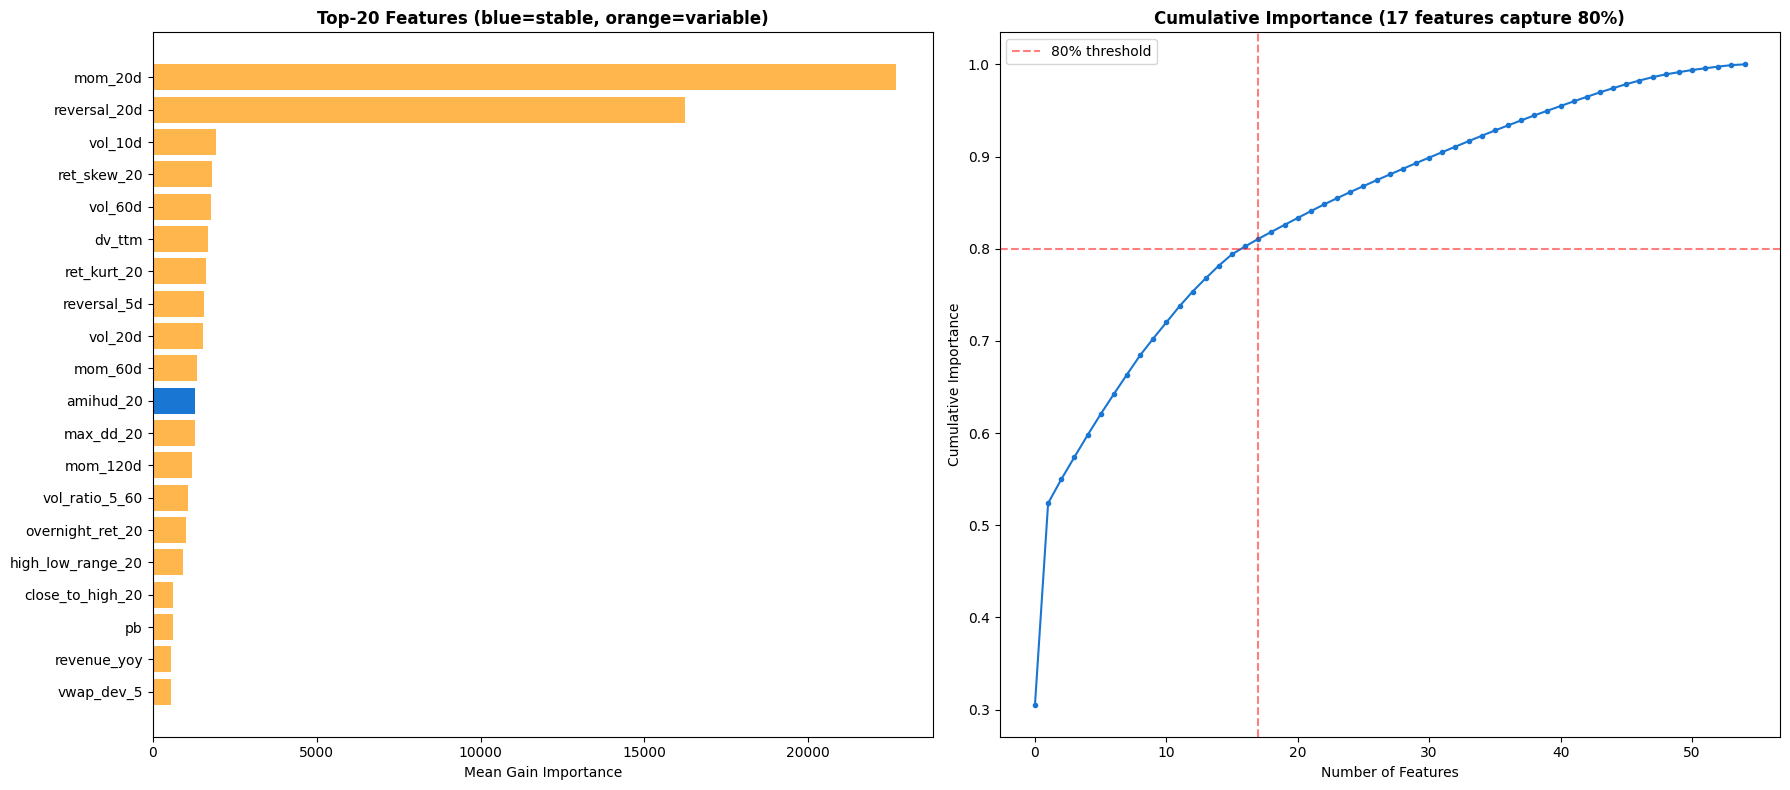

In [10]:
# ─── Feature importance (averaged across folds) ───
fi_all = pd.concat(fold_importances, axis=1)
fi_mean = fi_all.mean(axis=1).sort_values(ascending=False)
fi_std = fi_all.std(axis=1).reindex(fi_mean.index)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top-20 features
ax1 = axes[0]
top20 = fi_mean.head(20)
colors = ['#1976D2' if std/mean < 0.5 else '#FFB74D' 
          for mean, std in zip(top20.values, fi_std.head(20).values)]
ax1.barh(range(len(top20)), top20.values[::-1], color=colors[::-1])
ax1.set_yticks(range(len(top20)))
ax1.set_yticklabels(top20.index[::-1], fontsize=10)
ax1.set_xlabel('Mean Gain Importance')
ax1.set_title('Top-20 Features (blue=stable, orange=variable)', fontweight='bold')

# Cumulative importance
ax2 = axes[1]
cum_imp = (fi_mean / fi_mean.sum()).cumsum()
ax2.plot(range(len(cum_imp)), cum_imp.values, 'o-', markersize=3, color='#1976D2')
ax2.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='80% threshold')
n_80 = (cum_imp <= 0.8).sum() + 1
ax2.axvline(n_80, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Number of Features')
ax2.set_ylabel('Cumulative Importance')
ax2.set_title(f'Cumulative Importance ({n_80} features capture 80%)', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

## 7. Out-of-Sample Prediction Assembly

In [11]:
# ─── Concatenate OOS predictions ───
oos_pred = pd.concat(all_predictions)

# Remove duplicates (overlapping fold boundaries)
oos_pred = oos_pred[~oos_pred.index.duplicated(keep='last')]
oos_pred = oos_pred.sort_index()
oos_pred.name = 'score'

print(f'OOS Prediction Series:')
print(f'  Shape: {oos_pred.shape}')
print(f'  Date range: {oos_pred.index.get_level_values(0).min()} → {oos_pred.index.get_level_values(0).max()}')
print(f'  Unique dates: {oos_pred.index.get_level_values(0).nunique()}')
print(f'  Stocks/day: {len(oos_pred) / oos_pred.index.get_level_values(0).nunique():.0f}')

# OOS IC over the full period
label_aligned = label.reindex(oos_pred.index)
oos_ic = compute_ic_series(oos_pred, label_aligned)
oos_summary = compute_ic_summary(oos_ic)

print(f'\n=== Full OOS IC Summary ===')
for k, v in oos_summary.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')

OOS Prediction Series:
  Shape: (9730321,)
  Date range: 2016-01-04 00:00:00 → 2025-12-31 00:00:00
  Unique dates: 2430
  Stocks/day: 4004

=== Full OOS IC Summary ===
  mean_ic: 0.0341
  mean_rank_ic: 0.0399
  std_ic: 0.0383
  std_rank_ic: 0.0413
  icir: 0.8894
  rank_icir: 0.9655
  ic_hit_rate: 0.8391
  ic_positive_pct: 0.8391


## 8. Backtest: ML vs Linear vs CSI300

In [12]:
from src.backtest_engine.vectorized import VectorizedBacktester

bt = VectorizedBacktester(
    config_path=os.path.join(PROJECT_ROOT, 'config.yaml'),
    qlib_dir=QLIB_DIR,
)
print('Backtester initialized')

Backtester initialized


In [15]:
%%time
# ─── Run ML backtest ───
oos_start = str(oos_pred.index.get_level_values(0).min().date())
oos_end   = str(oos_pred.index.get_level_values(0).max().date())

# ─── Freeze signal to match 20-day prediction horizon ───
REBAL_PERIOD = FWD_DAYS  # Match rebalance to prediction horizon

dates = oos_pred.index.get_level_values(0).unique().sort_values()
rebal_dates = set(dates[::REBAL_PERIOD])

mask = oos_pred.index.get_level_values(0).isin(rebal_dates)
oos_pred_rebal = oos_pred.where(mask).groupby(level=1).ffill().dropna()
oos_pred_rebal.name = 'score'

print(f'Rebalance every {REBAL_PERIOD} days, {len(rebal_dates)} rebalance points')

result_ml_rebal = bt.run(
    predictions=oos_pred_rebal,
    start_time=oos_start,
    end_time=oos_end,
    topk=50,
    n_drop=50,  # Allow full rotation at rebalance points
    benchmark='000300_SH',
)

print('\n=== ML Strategy (20-day rebalance) ===')
print(result_ml_rebal)


[101048:MainThread](2026-03-06 15:51:30,845) INFO - qlib.backtest caller - [__init__.py:93] - Create new exchange


Rebalance every 20 days, 122 rebalance points


[101048:MainThread](2026-03-06 15:51:50,077) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[101048:MainThread](2026-03-06 15:51:50,081) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[101048:MainThread](2026-03-06 15:52:26,893) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x00000248824830A0>


backtest loop:   0%|          | 0/2430 [00:00<?, ?it/s]

e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  retur


=== ML Strategy (20-day rebalance) ===
BacktestResult (2430 days)
  annualized_return: -0.0519
  sharpe: -0.2580
  sortino: -0.3333
  max_drawdown: -0.7310
  volatility: 0.2011
  win_rate: 0.5214
  n_days: 2430
  excess_annualized_return: -0.0872
  information_ratio: -0.5430
CPU times: total: 1min 12s
Wall time: 1min 30s


In [ ]:
%%time
# ─── Run ML backtest ───
oos_start = str(oos_pred.index.get_level_values(0).min().date())
oos_end   = str(oos_pred.index.get_level_values(0).max().date())

print(f'OOS backtest period: {oos_start} → {oos_end}')

result_ml = bt.run(
    predictions=oos_pred,
    start_time=oos_start,
    end_time=oos_end,
    topk=50,
    n_drop=5,
    benchmark='000300_SH',
)

print('\n=== ML Strategy Backtest Summary ===')
print(result_ml)

[101048:MainThread](2026-03-06 15:19:21,290) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[101048:MainThread](2026-03-06 15:19:21,293) INFO - qlib.Initialization - [__init__.py:75] - qlib successfully initialized based on client settings.
[101048:MainThread](2026-03-06 15:19:21,295) INFO - qlib.Initialization - [__init__.py:77] - data_path={'__DEFAULT_FREQ': WindowsPath('E:/量化系统/data/qlib_data')}
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
[101048:MainThread](2026-03-06 15:19:21,381) INFO - qlib.backtest caller - [

OOS backtest period: 2016-01-04 → 2025-12-31


[101048:MainThread](2026-03-06 15:19:39,495) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[101048:MainThread](2026-03-06 15:19:39,499) WARNING - qlib.online operator - [exchange.py:219] - $close field data contains nan.
[101048:MainThread](2026-03-06 15:20:10,936) WARNING - qlib.data - [data.py:665] - load calendar error: freq=day, future=True; return current calendar!
[101048:MainThread](2026-03-06 15:20:10,936) WARNING - qlib.data - [data.py:668] - You can get future calendar by referring to the following document: https://github.com/microsoft/qlib/blob/main/scripts/data_collector/contrib/README.md
[101048:MainThread](2026-03-06 15:20:10,942) WARNING - qlib.BaseExecutor - [executor.py:121] - `common_infra` is not set for <qlib.backtest.executor.SimulatorExecutor object at 0x000002479E804B20>


backtest loop:   0%|          | 0/2430 [00:00<?, ?it/s]

e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  retur


=== ML Strategy Backtest Summary ===
BacktestResult (2430 days)
  annualized_return: -0.0216
  sharpe: -0.0961
  sortino: -0.1217
  max_drawdown: -0.6358
  volatility: 0.2250
  win_rate: 0.5272
  n_days: 2430
  excess_annualized_return: -0.0586
  information_ratio: -0.3538
CPU times: total: 48.9 s
Wall time: 1min 5s


e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)
e:\量化系统\venv\lib\site-packages\qlib\utils\index_data.py:492: RuntimeWarning: Mean of empty slice
  return np.nanmean(self.data)


=== Quantile Mean Returns (Q0=lowest pred, Q9=highest pred) ===
  Q0: -0.663%
  Q1: -0.460%
  Q2: -0.308%
  Q3: -0.155%
  Q4: -0.045%
  Q5: 0.071%
  Q6: 0.179%
  Q7: 0.306%
  Q8: 0.434%
  Q9: 0.559%

  Long-Short spread (Q9-Q0): 1.222%
  Monotonic? True

=== Size Bias Check (sample: 2020-12-29) ===
  Top-50 median market cap: 139亿
  Universe median market cap: 55亿
  Ratio: 2.53x


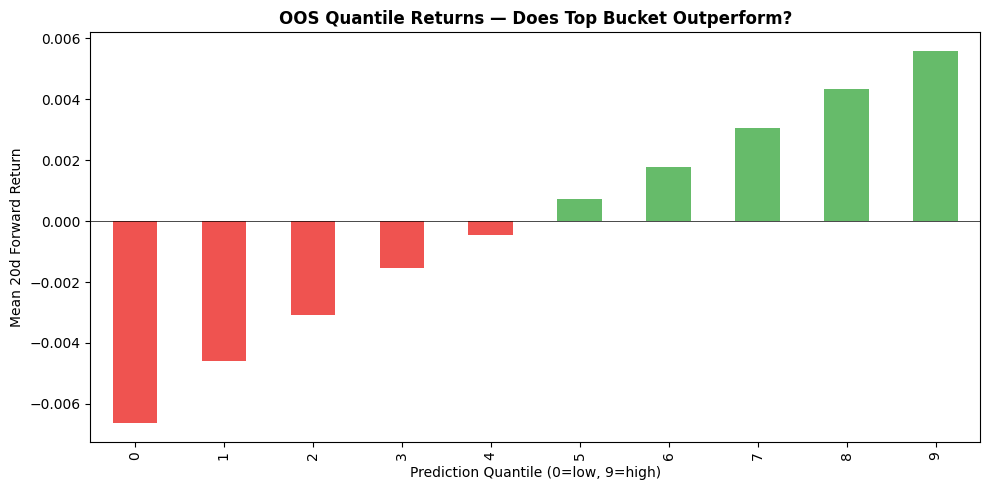

In [16]:
# ─── Diagnose IC-to-backtest gap ───────────────────────

# 1. Quantile analysis: does the TOP bucket actually outperform?
n_q = 10
dates = oos_pred.index.get_level_values(0).unique()
quantile_rets = []

for dt in dates:
    try:
        pred_cs = oos_pred.loc[dt]
        ret_cs = label.loc[dt]
        merged = pd.concat([pred_cs, ret_cs], axis=1, keys=['pred', 'ret']).dropna()
        if len(merged) < 100:
            continue
        merged['q'] = pd.qcut(merged['pred'], n_q, labels=False, duplicates='drop')
        q_mean = merged.groupby('q')['ret'].mean()
        q_mean.name = dt
        quantile_rets.append(q_mean)
    except:
        pass

q_df = pd.DataFrame(quantile_rets)
q_means = q_df.mean()

print("=== Quantile Mean Returns (Q0=lowest pred, Q9=highest pred) ===")
for q in range(n_q):
    if q in q_means.index:
        print(f"  Q{q}: {q_means[q]*100:.3f}%")

long_short = q_means.iloc[-1] - q_means.iloc[0]
print(f"\n  Long-Short spread (Q9-Q0): {long_short*100:.3f}%")
print(f"  Monotonic? {q_means.is_monotonic_increasing}")

# 2. What does the top-50 look like?
sample_date = dates[len(dates)//2]
pred_sample = oos_pred.loc[sample_date].sort_values(ascending=False)
top50 = pred_sample.head(50).index.tolist()

# Check market cap of top-50 vs universe
try:
    mv = D.features(D.instruments('all_stocks'), ['$total_mv'],
                    start_time=str(sample_date.date()), end_time=str(sample_date.date()))
    mv = mv.swaplevel()
    mv.columns = ['mv']
    mv_cs = mv.loc[sample_date, 'mv']
    
    top50_mv = mv_cs.reindex(top50).median()
    universe_mv = mv_cs.median()
    print(f"\n=== Size Bias Check (sample: {sample_date.date()}) ===")
    print(f"  Top-50 median market cap: {top50_mv/1e4:.0f}亿")
    print(f"  Universe median market cap: {universe_mv/1e4:.0f}亿")
    print(f"  Ratio: {top50_mv/universe_mv:.2f}x")
except Exception as e:
    print(f"  Size check failed: {e}")

# 3. Visualize quantile returns
fig, ax = plt.subplots(figsize=(10, 5))
q_means.plot(kind='bar', ax=ax, color=['#ef5350' if v < 0 else '#66bb6a' for v in q_means])
ax.set_xlabel('Prediction Quantile (0=low, 9=high)')
ax.set_ylabel(f'Mean {FWD_DAYS}d Forward Return')
ax.set_title('OOS Quantile Returns — Does Top Bucket Outperform?', fontweight='bold')
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


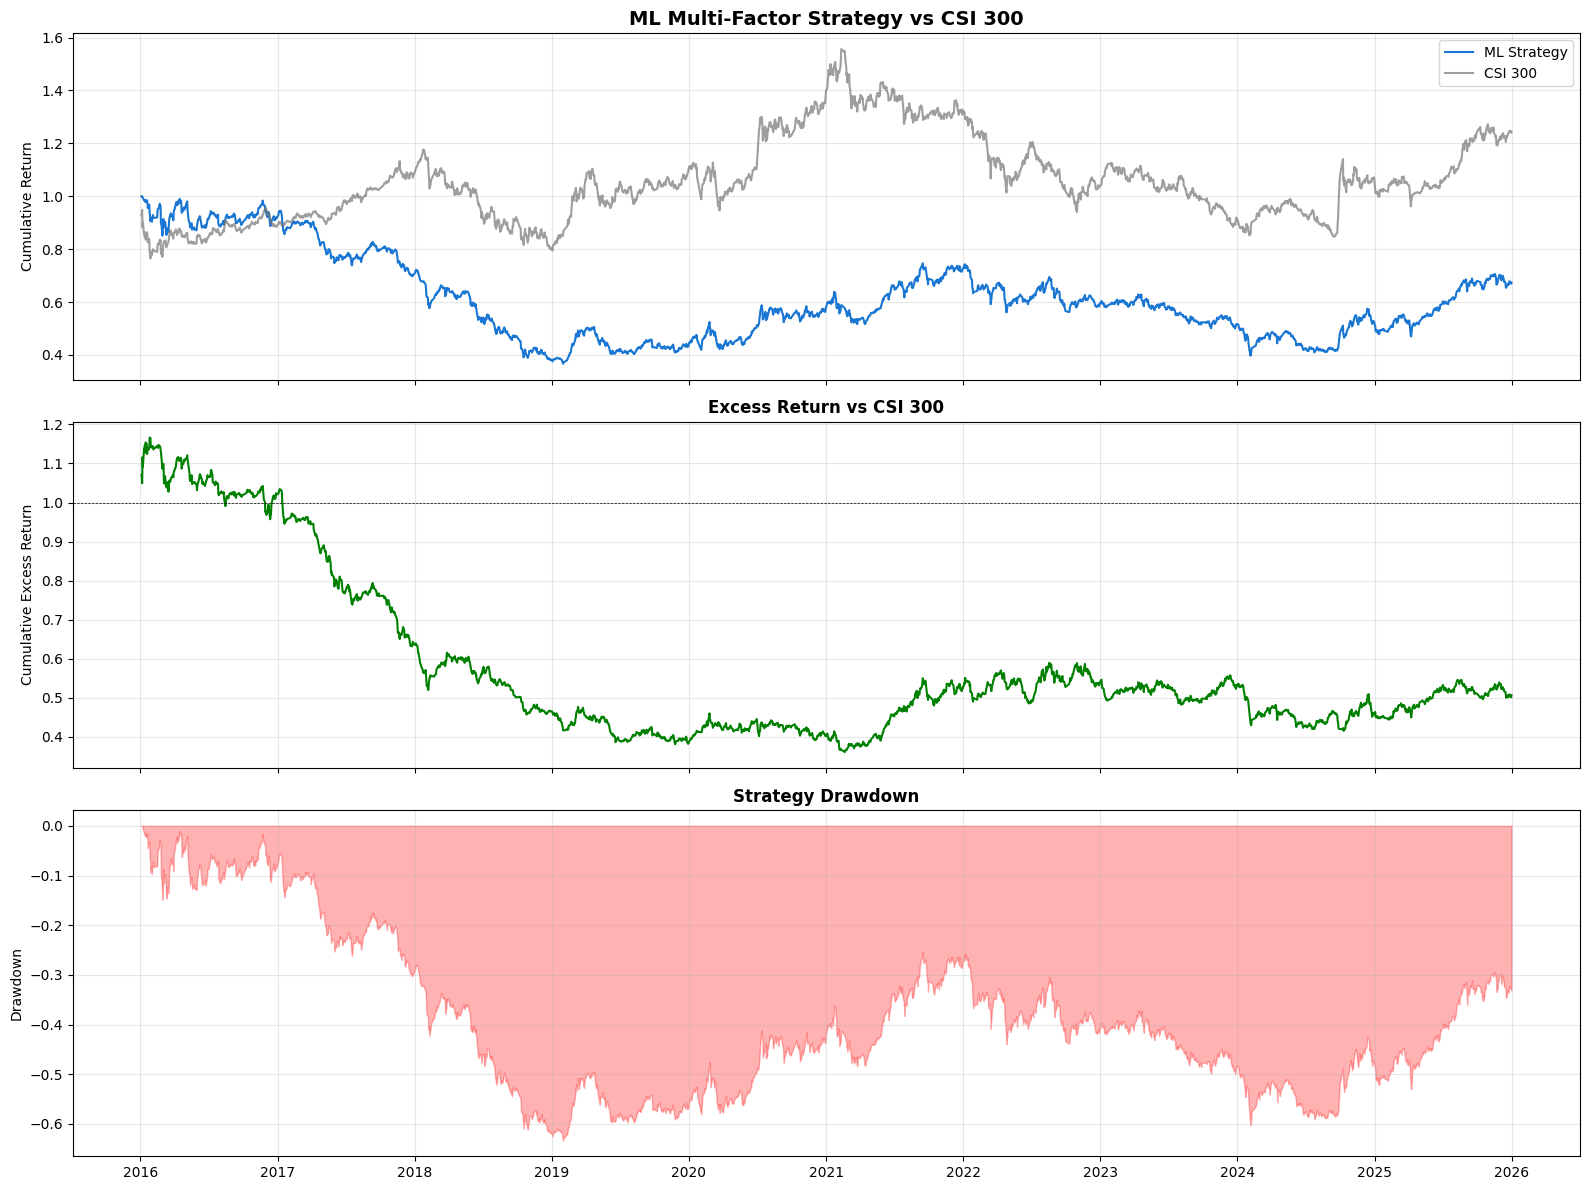

In [14]:
# ─── Equity curve + Drawdown ───
if result_ml.report is not None:
    report = result_ml.report
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    # Panel 1: Cumulative returns
    cum_ret = (1 + report['return']).cumprod()
    cum_bench = (1 + report['bench']).cumprod()
    axes[0].plot(cum_ret.index, cum_ret.values, label='ML Strategy', linewidth=1.5, color='#1976D2')
    axes[0].plot(cum_bench.index, cum_bench.values, label='CSI 300', linewidth=1.5, alpha=0.7, color='#757575')
    axes[0].set_ylabel('Cumulative Return')
    axes[0].set_title('ML Multi-Factor Strategy vs CSI 300', fontweight='bold', fontsize=14)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Panel 2: Excess return
    excess = report['return'] - report['bench']
    cum_excess = (1 + excess).cumprod()
    axes[1].plot(cum_excess.index, cum_excess.values, color='green', linewidth=1.5)
    axes[1].axhline(1, color='black', linewidth=0.5, linestyle='--')
    axes[1].set_ylabel('Cumulative Excess Return')
    axes[1].set_title('Excess Return vs CSI 300', fontweight='bold')
    axes[1].grid(alpha=0.3)

    # Panel 3: Drawdown
    peak = cum_ret.expanding().max()
    dd = (cum_ret - peak) / peak
    axes[2].fill_between(dd.index, dd.values, 0, color='red', alpha=0.3)
    axes[2].set_ylabel('Drawdown')
    axes[2].set_title('Strategy Drawdown', fontweight='bold')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 9. Experiment Logging (MLflow)

Log model parameters, per-fold metrics, and feature importance.

In [ ]:
# ─── MLflow logging (optional — skip if MLflow server not running) ───
LOG_TO_MLFLOW = False  # Set True if MLflow is running

if LOG_TO_MLFLOW:
    from src.alpha_research.mlflow_tracker import ExperimentTracker
    tracker = ExperimentTracker(config_path=os.path.join(PROJECT_ROOT, 'config.yaml'))
    tracker.start_run(run_name='ml_lgb_walkforward')

    # Params
    tracker.log_params({
        'model': 'LightGBM',
        'n_features': len(feature_cols),
        'fwd_days': FWD_DAYS,
        'train_years': TRAIN_YEARS,
        'valid_years': VALID_YEARS,
        'test_years': TEST_YEARS,
        'n_folds': len(folds),
        'topk': 50,
        'n_drop': 5,
    })

    # OOS metrics
    tracker.log_metrics({
        'oos_rank_ic': oos_summary.get('mean_rank_ic', 0),
        'oos_rank_icir': oos_summary.get('rank_icir', 0),
        **{k: v for k, v in result_ml.summary.items() if isinstance(v, (int, float))},
    })

    tracker.end_run()
    print('Logged to MLflow')
else:
    print('MLflow logging skipped (set LOG_TO_MLFLOW = True to enable)')

## Summary

| Aspect | Detail |
|--------|--------|
| Model | LightGBM (gradient boosting) |
| Features | ~60 engineered alpha factors |
| Validation | Walk-forward (3yr/1yr/1yr) |
| Strategy | TopkDropout(50), daily rebalance |
| Benchmark | CSI 300 (000300_SH) |

### Next Steps
1. **Hyperparameter tuning** — Optuna/Hyperopt search over LightGBM params
2. **Feature selection** — Drop features below importance threshold
3. **Ensemble** — Combine LightGBM + XGBoost + linear for diversity
4. **Rebalance frequency** — Test weekly/monthly instead of daily
5. **Risk overlay** — Add drawdown control and position sizing